## cnn on mnist

In [1]:
!pip install tensorflow -q

In [7]:
from tensorflow.keras.datasets import mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


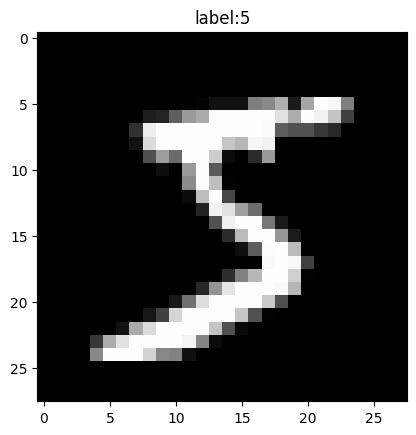

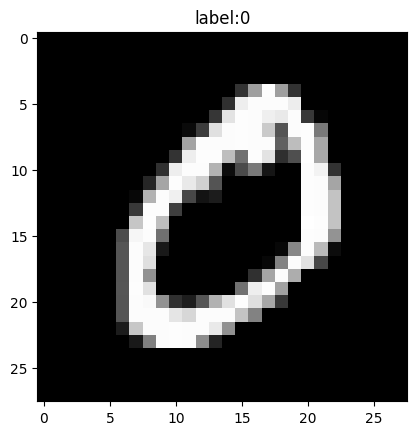

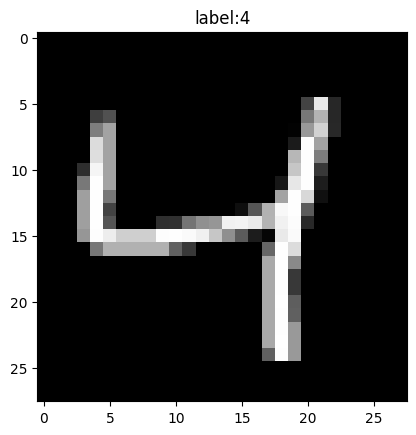

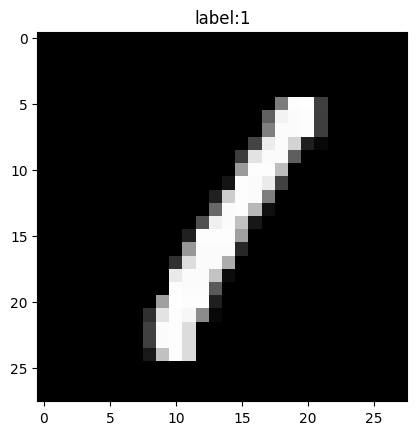

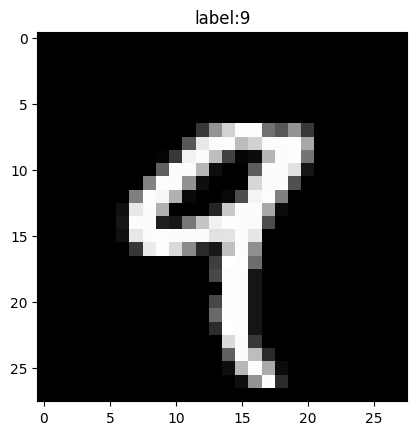

In [8]:
#visualize some imgs

for i in range(5):
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"label:{y_train[i]}")
    plt.show()

In [9]:
#preprocessing

#normalize
x_train=x_train/255.0
x_test=x_test/255.0

#reshape
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [11]:
# cnn model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model=Sequential()  #stacked model

model.add(Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)))  #32 filters -> learns basic features
model.add(MaxPooling2D((2,2)))  #1st pooling -> reduce size of ft.map
model.add(Conv2D(64,(3,3),activation='relu'))  #64 filters -> more feature learning
model.add(MaxPooling2D((2,2)))  #2nd pooling -> size reduces further

model.add(Flatten())  #1D kar deta hai sabko
model.add(Dense(64,activation='relu'))  #fully connected
model.add(Dense(10,activation='softmax'))  #output layer -> 10 neurons with softmax cuz 10 digits

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [13]:
#train model

history=model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9547 - loss: 0.1474 - val_accuracy: 0.9788 - val_loss: 0.0646
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9848 - loss: 0.0500 - val_accuracy: 0.9868 - val_loss: 0.0397
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9890 - loss: 0.0344 - val_accuracy: 0.9865 - val_loss: 0.0382
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9924 - loss: 0.0244 - val_accuracy: 0.9892 - val_loss: 0.0358
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9938 - loss: 0.0194 - val_accuracy: 0.9893 - val_loss: 0.0339


In [14]:
loss,acc=model.evaluate(x_test,y_test)
print("accuracy:",acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9893 - loss: 0.0339
accuracy: 0.989300012588501


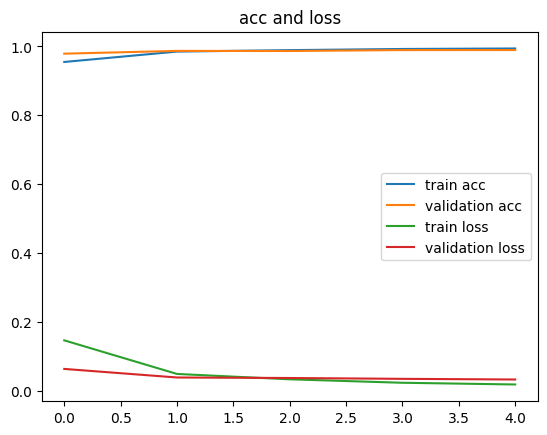

In [15]:
#plot acc and loss

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='validation acc')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title("acc and loss")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


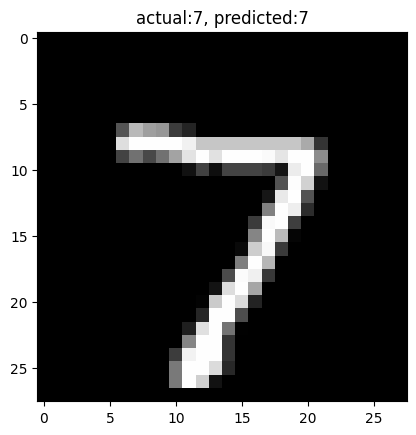

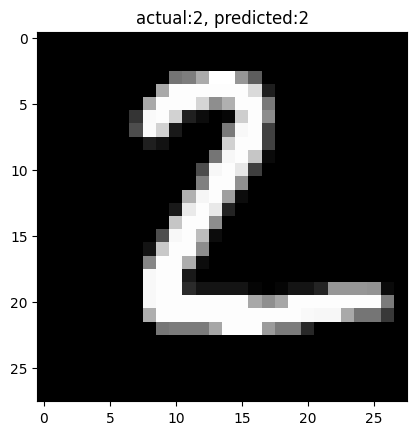

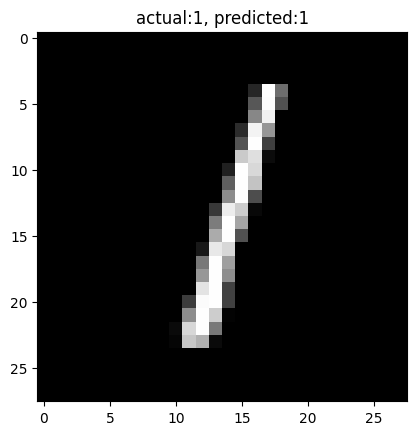

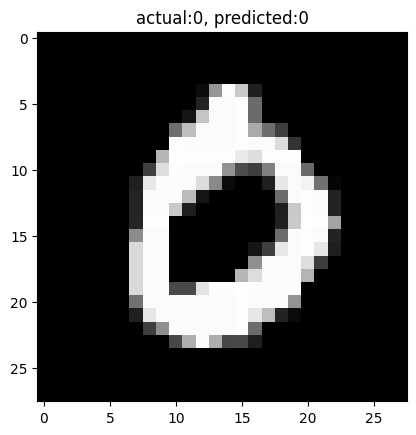

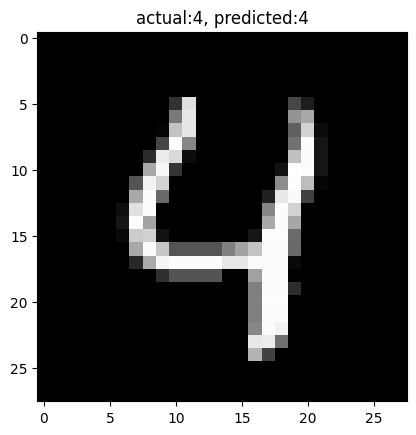

In [16]:
#predictions

import numpy as np
pred=model.predict(x_test)
for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"actual:{y_test[i]}, predicted:{np.argmax(pred[i])}")
    plt.show()

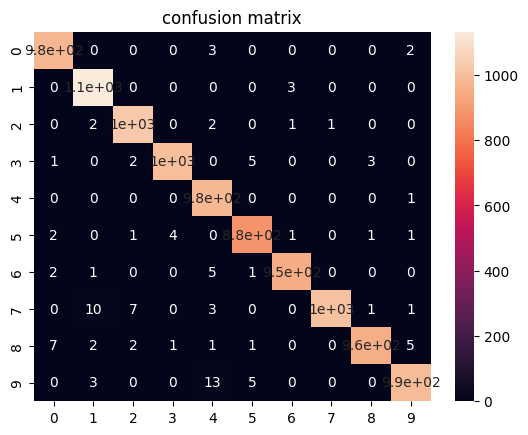

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred=pred.argmax(axis=1)
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.title("confusion matrix")
plt.show()